# QAPINN : Extended Qubit Sweep (3 → 8)



## 1. Dependencies 

In [1]:
import importlib, subprocess, sys
def ensure(pkg, pipname=None):
    try:
        importlib.import_module(pkg); print(f"[ok] {pkg}")
    except ImportError:
        print(f"[..] installing {pipname or pkg}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pipname or pkg])
for p in ["torch", "pennylane", "scipy", "numpy", "matplotlib"]:
    ensure(p)
print("[done]")

[ok] torch
[ok] pennylane
[ok] scipy
[ok] numpy
[ok] matplotlib
[done]


## 2. Imports & configuration

In [2]:
import os, time, math, json
import numpy as np
import torch
import torch.nn as nn
import pennylane as qml
from scipy.stats import qmc
import matplotlib.pyplot as plt

SEED = 1234
np.random.seed(SEED); torch.manual_seed(SEED)

DTYPE = torch.float32
torch.set_default_dtype(DTYPE)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CKPT_ROOT = "qapinn_runs"
for sub in ["checkpoints", "results", "figures", "models"]:
    os.makedirs(os.path.join(CKPT_ROOT, sub), exist_ok=True)

N_U = 120          # IC+BC points
print(f"[cfg] torch {torch.__version__} | pennylane {qml.__version__} | {device} | {DTYPE}")

[cfg] torch 2.10.0 | pennylane 0.45.1 | cpu | torch.float32


## 3. The two PDEs + training-data maker
Both live on $x\in[-1,1],\ t\in[0,1]$ with zero boundary conditions, so all code is shared:

- **Burgers**: $u_t + u\,u_x - \nu\,u_{xx} = 0$, $u(0,x)=-\sin(\pi x)$. Tier 1 uses $\nu=0.05$
  (moderate front, resolvable); Tier 2 uses the hard $\nu=0.01/\pi$ (sharp shock).
- **Heat**: $u_t - \alpha\,u_{xx} = 0$, $u(0,x)=\sin(\pi x)$, exact solution
  $\sin(\pi x)e^{-\alpha\pi^2 t}$ with $\alpha=0.1$ (nice dynamic range over $t\in[0,1]$).


In [3]:
NU_EASY  = 0.05          # Tier-1 Burgers viscosity
NU_HARD  = 0.01/np.pi    # Tier-2 Burgers viscosity (Raissi/Shah benchmark)
ALPHA    = 0.10          # Heat diffusivity

def initial_condition(pde, x):
    return -np.sin(np.pi*x) if pde == "burgers" else np.sin(np.pi*x)

def make_training_data(pde, n_f, tmax=1.0, shock_frac=0.0, seed=SEED):
    """Returns torch tensors (x_u,t_u,u_u, x_f,t_f) on the right device/dtype."""
    rng = np.random.default_rng(seed)
    # initial-condition points
    n_ic = N_U // 2
    x_ic = rng.uniform(-1, 1, n_ic); t_ic = np.zeros(n_ic)
    u_ic = initial_condition(pde, x_ic)
    # boundary points
    n_bc = N_U - n_ic
    t_bc = rng.uniform(0, tmax, n_bc)
    x_bc = np.where(rng.random(n_bc) < 0.5, -1.0, 1.0)
    u_bc = np.zeros(n_bc)
    x_u = np.concatenate([x_ic, x_bc]).reshape(-1, 1)
    t_u = np.concatenate([t_ic, t_bc]).reshape(-1, 1)
    u_u = np.concatenate([u_ic, u_bc]).reshape(-1, 1)
    # collocation: LHS base + optional shock-focused extra (Burgers only)
    n_sh = int(shock_frac * n_f) if pde == "burgers" else 0
    n_lhs = n_f - n_sh
    lhs = qmc.LatinHypercube(d=2, seed=seed)
    s = lhs.random(n_lhs)
    x_f1 = -1.0 + 2.0*s[:, 0]; t_f1 = tmax*s[:, 1]
    x_f2 = np.clip(rng.normal(0.0, 0.15, n_sh), -1, 1)
    t_f2 = rng.uniform(0.25*tmax, tmax, n_sh)
    x_f = np.concatenate([x_f1, x_f2]).reshape(-1, 1)
    t_f = np.concatenate([t_f1, t_f2]).reshape(-1, 1)
    T = lambda a: torch.tensor(a, dtype=DTYPE, device=device)
    return T(x_u), T(t_u), T(u_u), T(x_f), T(t_f)

print("[ok] data maker ready")

[ok] data maker ready


## 4. Reference solutions (exact, cached)
- Heat: closed form.
- Burgers (any ν): the Phase-1 Cole–Hopf quadrature.

Each reference grid (256×256) is computed once and cached to disk; `relative_l2` measures
$\|\hat u - u\| / \|u\|$ against it.

In [4]:
def burgers_analytical(x_arr, t_arr, nu, n_quad=4000):
    x_arr = np.atleast_1d(np.asarray(x_arr, float)); t_arr = np.atleast_1d(np.asarray(t_arr, float))
    u = np.zeros((len(t_arr), len(x_arr)))
    y = np.linspace(-3.0, 3.0, n_quad)
    cos_term = np.cos(np.pi*y) / (2.0*np.pi*nu)
    for i, ti in enumerate(t_arr):
        if ti < 1e-12:
            u[i, :] = -np.sin(np.pi*x_arr); continue
        F = cos_term.reshape(1, -1) + (x_arr.reshape(-1, 1) - y.reshape(1, -1))**2/(4.0*nu*ti)
        ml = np.max(-F, axis=1, keepdims=True); w = np.exp(-F - ml)
        num = np.sum((x_arr.reshape(-1, 1) - y.reshape(1, -1))/ti * w, axis=1)
        den = np.sum(w, axis=1)
        u[i, :] = np.where(den > 0, num/den, 0.0)
    return u

_REFS = {}
def reference(pde, nu):
    key = (pde, round(float(nu), 8))
    if key in _REFS: return _REFS[key]
    path = os.path.join(CKPT_ROOT, "results", f"ref_{pde}_{nu:.6f}.npz")
    if os.path.exists(path):
        d = np.load(path); out = (d["x"], d["t"], d["U"])
    else:
        x = np.linspace(-1, 1, 256); t = np.linspace(0, 1, 256)
        if pde == "heat":
            U = np.sin(np.pi*x)[None, :] * np.exp(-nu*np.pi**2*t)[:, None]
        else:
            print(f"[ref] computing Cole-Hopf for nu={nu:.5f} (once, ~20s)...")
            U = burgers_analytical(x, t, nu)
        np.savez(path, x=x, t=t, U=U); out = (x, t, U)
    _REFS[key] = out
    return out

@torch.no_grad()
def relative_l2(model, pde, nu):
    x, t, U = reference(pde, nu)
    XX, TT = np.meshgrid(x, t)
    xf = torch.tensor(XX.reshape(-1, 1), dtype=DTYPE, device=device)
    tf = torch.tensor(TT.reshape(-1, 1), dtype=DTYPE, device=device)
    up = model(xf, tf).cpu().numpy().reshape(U.shape)
    return float(np.linalg.norm(up - U)/np.linalg.norm(U)), up

def frozen_ic_baseline(pde, nu):
    """L2 of predicting the initial condition for all t -- the honest 'no-dynamics' bar."""
    x, t, U = reference(pde, nu)
    IC = np.tile(initial_condition(pde, x), (len(t), 1))
    return float(np.linalg.norm(IC - U)/np.linalg.norm(U))

print("[ok] references ready")

[ok] references ready


## 5. The QAPINN model 

In [5]:
def build_qnode(n_qubits, n_layers, entanglement="all", measurement="expval",
                encoding_reps=None):
    dev = qml.device("default.qubit", wires=n_qubits)
    reps = n_layers if encoding_reps is None else encoding_reps
    def entangle():
        if entanglement == "none": return
        if entanglement == "linear":
            for q in range(n_qubits - 1): qml.CNOT(wires=[q, q + 1])
        elif entanglement == "all":
            for a in range(n_qubits):
                for b in range(a + 1, n_qubits): qml.CNOT(wires=[a, b])
    @qml.qnode(dev, interface="torch", diff_method="backprop")
    def circuit(inputs, weights):
        for l in range(n_layers):
            if l < reps:                                  # data re-uploading
                for q in range(n_qubits):
                    qml.RY(inputs[:, q % 2], wires=q)
            for q in range(n_qubits):
                qml.RX(weights[l, q], wires=q)
            entangle()
        if measurement == "expval":
            return [qml.expval(qml.PauliZ(q)) for q in range(n_qubits)]
        return qml.probs(wires=range(n_qubits))
    out_dim = n_qubits if measurement == "expval" else 2**n_qubits
    return circuit, {"weights": (n_layers, n_qubits)}, out_dim


class QAPINN(nn.Module):
    """VQC first layer (re-uploading, trainable input scale) + deep classical body."""
    def __init__(self, n_qubits=3, n_layers=6, entanglement="all", measurement="expval",
                 encoding_reps=None, head_width=20, head_depth=5):
        super().__init__()
        self.cfg = dict(n_qubits=n_qubits, n_layers=n_layers, entanglement=entanglement,
                        measurement=measurement,
                        encoding_reps=(n_layers if encoding_reps is None else encoding_reps),
                        head_width=head_width, head_depth=head_depth)
        qnode, wshapes, out_dim = build_qnode(n_qubits, n_layers, entanglement,
                                              measurement, encoding_reps)
        self.qlayer = qml.qnn.TorchLayer(qnode, wshapes)
        self.in_scale = nn.Parameter(torch.ones(2))
        layers = [nn.Linear(out_dim, head_width), nn.Tanh()]
        for _ in range(head_depth - 1):
            layers += [nn.Linear(head_width, head_width), nn.Tanh()]
        layers += [nn.Linear(head_width, 1)]
        self.head = nn.Sequential(*layers)
        for m in self.head:                                # Xavier init (as Phase 1)
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x, t):
        inp = torch.cat([x, t], dim=1) * self.in_scale * math.pi
        feat = self.qlayer(inp)
        return self.head(feat)

def count_params(model):
    return sum(p.numel() for p in model.parameters())

_m = QAPINN(3)
print(f"[ok] model ready — 3-qubit example: {count_params(_m)} params "
      f"(vs 101 in the failed v3, 3021 in Phase 1)")
del _m

[ok] model ready — 3-qubit example: 1801 params (vs 101 in the failed v3, 3021 in Phase 1)


## 6. Physics-informed loss (PDE-aware, exact autograd derivatives)

In [6]:
W_IC = 10.0

def pinn_loss(model, x_u, t_u, u_u, x_f, t_f, pde, nu, w_ic=None):
    w = W_IC if w_ic is None else w_ic
    u_pred = model(x_u, t_u)
    mse_u = torch.mean((u_pred - u_u)**2)
    xf = x_f.clone().requires_grad_(True)
    tf = t_f.clone().requires_grad_(True)
    u = model(xf, tf)
    u_x = torch.autograd.grad(u, xf, torch.ones_like(u), create_graph=True)[0]
    u_t = torch.autograd.grad(u, tf, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, xf, torch.ones_like(u_x), create_graph=True)[0]
    if pde == "burgers":
        f = u_t + u*u_x - nu*u_xx
    else:                              # heat
        f = u_t - nu*u_xx
    mse_f = torch.mean(f**2)
    return w*mse_u + mse_f, mse_u, mse_f
print("[ok] loss ready")

[ok] loss ready


## 7. Schedule-based training engine 

In [7]:
def ckpt_path(tag):
    return os.path.join(CKPT_ROOT, "checkpoints", f"{tag}.pt")

def _state_copy(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

def train_schedule(tag, model, pde, nu, schedule, n_f=2000,
                   ckpt_every=250, log_every=100):
    model.to(device)
    hist = {"iters": [], "loss": [], "mse_u": [], "mse_f": [], "phase": []}
    start_phase, start_it, opt_state = 0, 0, None
    best_loss, best_state = float("inf"), None
    p = ckpt_path(tag)
    if os.path.exists(p):
        ck = torch.load(p, map_location=device, weights_only=False)
        model.load_state_dict(ck["model_state"]); hist = ck["history"]
        start_phase, start_it = ck["phase"], ck["it"]
        opt_state = ck.get("opt_state")
        best_loss = ck.get("best_loss", best_loss); best_state = ck.get("best_state")
        print(f"[resume] '{tag}' at phase {start_phase}, it {start_it}")
    if start_phase >= len(schedule):
        print(f"[done] '{tag}' already finished. Delete its checkpoint to redo.")
        return hist

    cur = {"phase": start_phase, "it": start_it, "opt": None}
    def save():
        tmp = p + ".tmp"
        torch.save({"phase": cur["phase"], "it": cur["it"],
                    "model_state": model.state_dict(),
                    "opt_state": (cur["opt"].state_dict() if cur["opt"] is not None else None),
                    "history": hist, "best_loss": best_loss, "best_state": best_state}, tmp)
        os.replace(tmp, p)

    gstep = len(hist["loss"])
    t0 = time.time()
    try:
        for pi in range(start_phase, len(schedule)):
            ph = schedule[pi]
            cur["phase"] = pi
            x_u, t_u, u_u, x_f, t_f = make_training_data(
                pde, n_f, tmax=ph.get("tmax", 1.0),
                shock_frac=ph.get("shock_frac", 0.0), seed=SEED + 13*pi)
            it0 = start_it if pi == start_phase else 0

            if ph["kind"] == "adam":
                opt = torch.optim.Adam(model.parameters(), lr=ph.get("lr", 8e-3))
                cur["opt"] = opt
                if pi == start_phase and opt_state is not None:
                    try: opt.load_state_dict(opt_state)
                    except Exception: pass
                for it in range(it0, ph["iters"]):
                    cur["it"] = it
                    opt.zero_grad()
                    loss, mu, mf = pinn_loss(model, x_u, t_u, u_u, x_f, t_f, pde=pde, nu=nu)
                    loss.backward(); opt.step()
                    li = loss.item(); gstep += 1
                    hist["iters"].append(gstep); hist["loss"].append(li)
                    hist["mse_u"].append(mu.item()); hist["mse_f"].append(mf.item())
                    hist["phase"].append(pi)
                    if math.isfinite(li) and li < best_loss:
                        best_loss, best_state = li, _state_copy(model)
                    if (it + 1) % log_every == 0:
                        print(f"  [{tag}] P{pi} adam it {it+1:5d}/{ph['iters']} "
                              f"loss={li:.3e} (u={mu.item():.2e}, f={mf.item():.2e}) "
                              f"[{(time.time()-t0)/60:.1f} min]")
                    if (it + 1) % ckpt_every == 0:
                        cur["it"] = it + 1; save()

            else:  # ---- L-BFGS phase, chunked ----
                chunk = ph.get("chunk", 150)
                opt = torch.optim.LBFGS(model.parameters(), max_iter=chunk,
                                        history_size=60, line_search_fn="strong_wolfe",
                                        tolerance_grad=1e-12, tolerance_change=1e-14)
                cur["opt"] = opt
                if pi == start_phase and opt_state is not None:
                    try: opt.load_state_dict(opt_state)
                    except Exception: pass
                n_chunks = math.ceil(ph["iters"]/chunk)
                for c in range(it0 // chunk, n_chunks):
                    def closure():
                        opt.zero_grad()
                        L, _, _ = pinn_loss(model, x_u, t_u, u_u, x_f, t_f, pde=pde, nu=nu)
                        L.backward(); return L
                    opt.step(closure)
                    loss, mu, mf = pinn_loss(model, x_u, t_u, u_u, x_f, t_f, pde=pde, nu=nu)
                    li = loss.item(); gstep += chunk
                    hist["iters"].append(gstep); hist["loss"].append(li)
                    hist["mse_u"].append(mu.item()); hist["mse_f"].append(mf.item())
                    hist["phase"].append(pi)
                    print(f"  [{tag}] P{pi} lbfgs chunk {c+1}/{n_chunks} "
                          f"loss={li:.3e} (u={mu.item():.2e}, f={mf.item():.2e}) "
                          f"[{(time.time()-t0)/60:.1f} min]")
                    if (not math.isfinite(li)) or li > 50*max(best_loss, 1e-12):
                        print(f"  [{tag}] L-BFGS blow-up guard triggered -> "
                              f"restoring best state (loss {best_loss:.3e}) and stopping phase.")
                        if best_state is not None:
                            model.load_state_dict(best_state)
                        break
                    if li < best_loss:
                        best_loss, best_state = li, _state_copy(model)
                    cur["it"] = (c + 1)*chunk; save()

            start_it = 0
            cur["phase"], cur["it"], cur["opt"] = pi + 1, 0, None
            save()

        # keep the best weights seen anywhere in training
        if best_state is not None and hist["loss"] and best_loss < hist["loss"][-1]*0.999:
            model.load_state_dict(best_state)
            print(f"[{tag}] restored overall best state (loss {best_loss:.3e})")
        save()
    except KeyboardInterrupt:
        save()
        print(f"\n[interrupted] '{tag}' checkpointed at phase {cur['phase']}, "
              f"it {cur['it']}. Re-run this cell to continue.")
        raise
    print(f"[finished] '{tag}' total wall time {(time.time()-t0)/60:.1f} min")
    return hist
print("[ok] engine ready")

[ok] engine ready


## 8. Results recorder (CSV + saved models + loss histories)

In [8]:
import csv
MASTER_CSV = os.path.join(CKPT_ROOT, "results", "master_results.csv")
FIELDS = ["tag","pde","nu","n_qubits","n_layers","entanglement","measurement",
          "encoding_reps","head_width","head_depth","optimizer","n_iters","params",
          "L2","mse_u","mse_f","final_loss"]

def record_result(tag, model, hist, pde, nu, optimizer="adam+lbfgs"):
    l2, _ = relative_l2(model, pde, nu)
    row = {"tag": tag, "pde": pde, "nu": f"{nu:.6f}", **model.cfg,
           "optimizer": optimizer,
           "n_iters": hist["iters"][-1] if hist["iters"] else 0,
           "params": count_params(model), "L2": f"{l2:.6e}",
           "mse_u": f"{hist['mse_u'][-1]:.6e}" if hist["mse_u"] else "",
           "mse_f": f"{hist['mse_f'][-1]:.6e}" if hist["mse_f"] else "",
           "final_loss": f"{hist['loss'][-1]:.6e}" if hist["loss"] else ""}
    row = {k: v for k, v in row.items() if k in FIELDS}
    exists = os.path.exists(MASTER_CSV)
    with open(MASTER_CSV, "a", newline="") as fh:
        w = csv.DictWriter(fh, fieldnames=FIELDS)
        if not exists: w.writeheader()
        w.writerow(row)
    torch.save(model.state_dict(), os.path.join(CKPT_ROOT, "models", f"{tag}.pt"))
    np.savez(os.path.join(CKPT_ROOT, "results", f"{tag}_history.npz"),
             iters=np.array(hist["iters"]), loss=np.array(hist["loss"]),
             mse_u=np.array(hist["mse_u"]), mse_f=np.array(hist["mse_f"]),
             phase=np.array(hist["phase"]))
    print(f"[record] {tag}: L2={l2:.3e}, params={count_params(model)}")
    return l2
print("[ok] recorder ready")

[ok] recorder ready


---
# The extended sweep



In [9]:
# ---- control panel -------------------------------------------------------
MAX_QUBITS = 8          # set to 6 or 7 if you want a shorter night
RUN_HEAT   = True       # set False to do Burgers only (recommended if time is tight)

# tiered budget: full convergence at 3-5, trend-only at 6-8
QUBIT_BUDGET = {
    3: dict(adam=2000, lbfgs=1600, chunk=200),
    4: dict(adam=2000, lbfgs=1600, chunk=200),
    5: dict(adam=2000, lbfgs=1600, chunk=200),
    6: dict(adam=1200, lbfgs=800,  chunk=200),
    7: dict(adam=800,  lbfgs=500,  chunk=250),
    8: dict(adam=500,  lbfgs=300,  chunk=150),
}
QUBITS = [q for q in [3, 4, 5, 6, 7, 8] if q <= MAX_QUBITS]

def schedule_for(nq, shock_frac):
    b = QUBIT_BUDGET[nq]
    return [
        {"kind": "adam",  "lr": 8e-3, "iters": b["adam"],  "tmax": 1.0, "shock_frac": shock_frac},
        {"kind": "lbfgs", "iters": b["lbfgs"], "chunk": b["chunk"], "tmax": 1.0,
         "shock_frac": shock_frac},
    ]

print("sweep:", QUBITS)
for q in QUBITS:
    b = QUBIT_BUDGET[q]
    print(f"  q{q}: adam {b['adam']}, lbfgs {b['lbfgs']} (chunks of {b['chunk']})")

sweep: [3, 4, 5, 6, 7, 8]
  q3: adam 2000, lbfgs 1600 (chunks of 200)
  q4: adam 2000, lbfgs 1600 (chunks of 200)
  q5: adam 2000, lbfgs 1600 (chunks of 200)
  q6: adam 1200, lbfgs 800 (chunks of 200)
  q7: adam 800, lbfgs 500 (chunks of 250)
  q8: adam 500, lbfgs 300 (chunks of 150)


## Burgers sweep (ν = 0.05), qubits 3 → 8
Same PDE and viscosity as the successful Tier 1 so the numbers are **directly comparable** to
`T1_burgers_q{3,4,5}` 

In [10]:
V5_burgers = {}
for nq in QUBITS:
    tag = f"V5_burgers_q{nq}"
    b = QUBIT_BUDGET[nq]
    print(f"\n=== {tag} ({nq} qubits | adam {b['adam']} + lbfgs {b['lbfgs']}) ===")
    model = QAPINN(n_qubits=nq, n_layers=6, entanglement="all",
                   measurement="expval", head_width=20, head_depth=5)
    print(f"    parameters: {count_params(model)}")
    hist = train_schedule(tag, model, "burgers", NU_EASY,
                          schedule_for(nq, shock_frac=0.15),
                          n_f=2000, ckpt_every=250, log_every=400)
    l2 = record_result(tag, model, hist, "burgers", NU_EASY)
    V5_burgers[nq] = (model, hist, l2)
    print(f"    --> L2 = {l2:.4e}")
print("\n[V5 Burgers sweep complete]")


=== V5_burgers_q3 (3 qubits | adam 2000 + lbfgs 1600) ===
    parameters: 1801
[resume] 'V5_burgers_q3' at phase 2, it 0
[done] 'V5_burgers_q3' already finished. Delete its checkpoint to redo.
[record] V5_burgers_q3: L2=3.622e-03, params=1801
    --> L2 = 3.6218e-03

=== V5_burgers_q4 (4 qubits | adam 2000 + lbfgs 1600) ===
    parameters: 1827
[resume] 'V5_burgers_q4' at phase 2, it 0
[done] 'V5_burgers_q4' already finished. Delete its checkpoint to redo.
[record] V5_burgers_q4: L2=5.857e-04, params=1827
    --> L2 = 5.8572e-04

=== V5_burgers_q5 (5 qubits | adam 2000 + lbfgs 1600) ===
    parameters: 1853
[resume] 'V5_burgers_q5' at phase 2, it 0
[done] 'V5_burgers_q5' already finished. Delete its checkpoint to redo.
[record] V5_burgers_q5: L2=1.161e-03, params=1853
    --> L2 = 1.1613e-03

=== V5_burgers_q6 (6 qubits | adam 1200 + lbfgs 800) ===
    parameters: 1879
[resume] 'V5_burgers_q6' at phase 2, it 0
[done] 'V5_burgers_q6' already finished. Delete its checkpoint to redo.
[re

## Gradient-variance probe : the barren-plateau measurement 



In [11]:
def gradient_variance(nq, pde="burgers", nu=NU_EASY, n_samples=25, n_f=400, seed=SEED):
    """Var of quantum-parameter gradient components over random inits."""
    x_u, t_u, u_u, x_f, t_f = make_training_data(pde, n_f, seed=seed)
    comps = []
    for s in range(n_samples):
        torch.manual_seed(seed + 1000*s)
        m = QAPINN(n_qubits=nq, n_layers=6, entanglement="all",
                   measurement="expval", head_width=20, head_depth=5).to(device)
        # random (not identity) quantum params -- the regime the theory describes
        with torch.no_grad():
            for p_ in m.qlayer.parameters():
                p_.uniform_(0, 2*math.pi)
        m.zero_grad()
        loss, _, _ = pinn_loss(m, x_u, t_u, u_u, x_f, t_f, pde=pde, nu=nu)
        loss.backward()
        g = torch.cat([p_.grad.flatten() for p_ in m.qlayer.parameters()])
        comps.append(g.detach().cpu().numpy())
    comps = np.concatenate(comps)
    return float(np.var(comps)), float(np.mean(np.abs(comps)))

GV = {}
print(f"{'qubits':>6} {'Var[dL/dtheta]':>16} {'mean|grad|':>12}")
for nq in QUBITS:
    t0 = time.time()
    v, mg = gradient_variance(nq)
    GV[nq] = v
    print(f"{nq:>6} {v:>16.4e} {mg:>12.4e}   ({time.time()-t0:.0f}s)")

np.savez(os.path.join(CKPT_ROOT, "results", "V5_gradient_variance.npz"),
         qubits=np.array(list(GV.keys())), var=np.array(list(GV.values())))

ks = sorted(GV)
print("\nsuccessive ratios (consistently < 1 => exponential decay => barren plateau):")
for i in range(1, len(ks)):
    print(f"  Var(q{ks[i]})/Var(q{ks[i-1]}) = {GV[ks[i]]/GV[ks[i-1]]:.3f}")
if len(ks) >= 3:
    sl = np.polyfit(ks, np.log(list(GV.values())), 1)[0]
    print(f"\nlog-linear fit: Var ~ exp({sl:.3f} * n_qubits)")
    print("  (a clearly negative slope is the quantitative barren-plateau signature)")

qubits   Var[dL/dtheta]   mean|grad|
     3       7.0225e-01   5.1338e-01   (8s)
     4       2.6642e-01   2.9519e-01   (13s)
     5       1.6942e-01   2.5191e-01   (21s)
     6       1.8532e-01   2.2858e-01   (37s)
     7       2.1895e-01   2.5411e-01   (72s)
     8       4.4432e-02   1.3133e-01   (114s)

successive ratios (consistently < 1 => exponential decay => barren plateau):
  Var(q4)/Var(q3) = 0.379
  Var(q5)/Var(q4) = 0.636
  Var(q6)/Var(q5) = 1.094
  Var(q7)/Var(q6) = 1.182
  Var(q8)/Var(q7) = 0.203

log-linear fit: Var ~ exp(-0.409 * n_qubits)
  (a clearly negative slope is the quantitative barren-plateau signature)


## Analysis : accuracy turning point + trainability



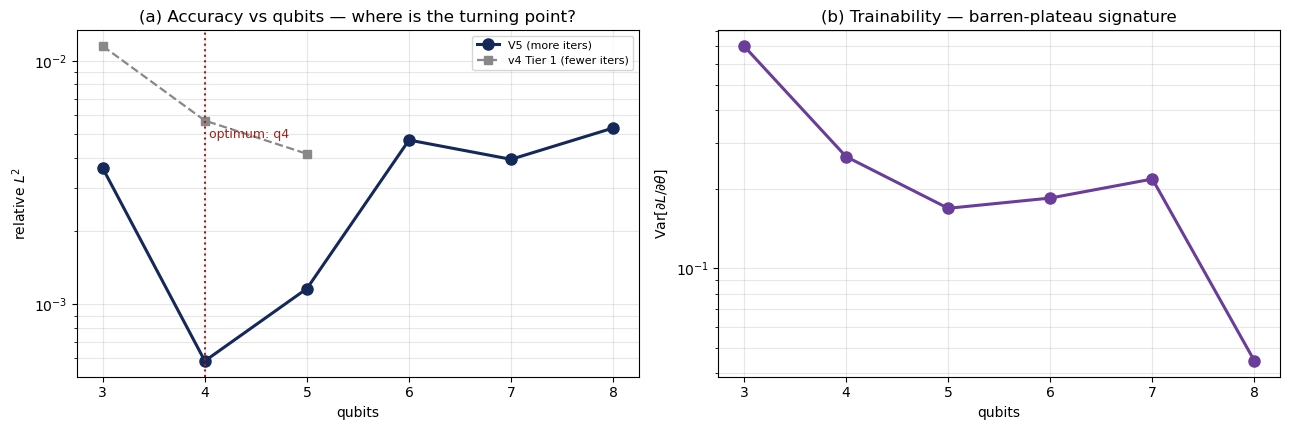

qubits  params     L2 (v5)     L2 (v4)    gain
     3    1801   3.622e-03   1.149e-02   3.17x
     4    1827   5.857e-04   5.683e-03   9.70x
     5    1853   1.161e-03   4.151e-03   3.57x
     6    1879   4.727e-03       -         -  
     7    1905   3.941e-03       -         -  
     8    1931   5.298e-03       -         -  

best qubit count: q4 (L2 = 5.857e-04)
-> accuracy DEGRADES beyond q4: this is the RQ3 'what is lost' result.


In [12]:
l2s = [V5_burgers[q][2] for q in QUBITS]
best_q = QUBITS[int(np.argmin(l2s))]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))

ax[0].semilogy(QUBITS, l2s, "o-", lw=2.2, ms=8, color="#14285a", label="V5 (more iters)")
old = {3: 1.1492e-02, 4: 5.6834e-03, 5: 4.1514e-03}     # your v4 Tier-1 results
oq = [q for q in QUBITS if q in old]
if oq:
    ax[0].semilogy(oq, [old[q] for q in oq], "s--", lw=1.6, ms=6, color="#888888",
                   label="v4 Tier 1 (fewer iters)")
ax[0].axvline(best_q, ls=":", color="#96261e", lw=1.5)
ax[0].text(best_q, max(l2s), f" optimum: q{best_q}", color="#96261e", fontsize=9, va="top")
ax[0].set_xlabel("qubits"); ax[0].set_ylabel("relative $L^2$")
ax[0].set_title("(a) Accuracy vs qubits — where is the turning point?")
ax[0].grid(True, which="both", alpha=0.3); ax[0].legend(fontsize=8); ax[0].set_xticks(QUBITS)

gq = sorted(GV)
ax[1].semilogy(gq, [GV[q] for q in gq], "o-", lw=2.2, ms=8, color="#6a3d9a")
ax[1].set_xlabel("qubits"); ax[1].set_ylabel(r"$\mathrm{Var}[\partial L/\partial\theta]$")
ax[1].set_title("(b) Trainability — barren-plateau signature")
ax[1].grid(True, which="both", alpha=0.3); ax[1].set_xticks(gq)

plt.tight_layout()
plt.savefig(os.path.join(CKPT_ROOT, "figures", "V5_turning_point.png"), dpi=150,
            bbox_inches="tight")
plt.show()

print(f"{'qubits':>6} {'params':>7} {'L2 (v5)':>11} {'L2 (v4)':>11} {'gain':>7}")
for q in QUBITS:
    m, h, l2 = V5_burgers[q]
    o = old.get(q)
    gain = f"{o/l2:.2f}x" if o else "  -  "
    ostr = f"{o:.3e}" if o else "    -    "
    print(f"{q:>6} {count_params(m):>7} {l2:>11.3e} {ostr:>11} {gain:>7}")
print(f"\nbest qubit count: q{best_q} (L2 = {min(l2s):.3e})")
if best_q < max(QUBITS):
    print(f"-> accuracy DEGRADES beyond q{best_q}: this is the RQ3 'what is lost' result.")
else:
    print("-> accuracy still improving at the largest qubit count tested;")
    print("   report that barren plateaus have not yet dominated at this scale.")

## Heat sweep (α = 0.1) : the contrast case



=== V5_heat_q3 (3 qubits | adam 2000 + lbfgs 1600) ===
[resume] 'V5_heat_q3' at phase 2, it 0
[done] 'V5_heat_q3' already finished. Delete its checkpoint to redo.
[record] V5_heat_q3: L2=1.159e-03, params=1801
    --> L2 = 1.1585e-03

=== V5_heat_q4 (4 qubits | adam 2000 + lbfgs 1600) ===
[resume] 'V5_heat_q4' at phase 2, it 0
[done] 'V5_heat_q4' already finished. Delete its checkpoint to redo.
[record] V5_heat_q4: L2=6.980e-04, params=1827
    --> L2 = 6.9801e-04

=== V5_heat_q5 (5 qubits | adam 2000 + lbfgs 1600) ===
[resume] 'V5_heat_q5' at phase 2, it 0
[done] 'V5_heat_q5' already finished. Delete its checkpoint to redo.
[record] V5_heat_q5: L2=5.801e-04, params=1853
    --> L2 = 5.8013e-04

=== V5_heat_q6 (6 qubits | adam 1200 + lbfgs 800) ===
[resume] 'V5_heat_q6' at phase 2, it 0
[done] 'V5_heat_q6' already finished. Delete its checkpoint to redo.
[record] V5_heat_q6: L2=8.305e-04, params=1879
    --> L2 = 8.3047e-04

=== V5_heat_q7 (7 qubits | adam 800 + lbfgs 500) ===
[resume

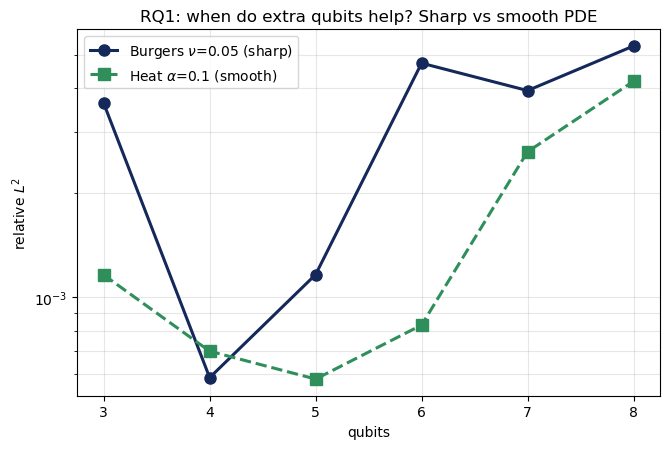

Burgers optimum: q4   |   Heat optimum: q5


In [13]:
V5_heat = {}
if RUN_HEAT:
    for nq in QUBITS:
        tag = f"V5_heat_q{nq}"
        b = QUBIT_BUDGET[nq]
        print(f"\n=== {tag} ({nq} qubits | adam {b['adam']} + lbfgs {b['lbfgs']}) ===")
        model = QAPINN(n_qubits=nq, n_layers=6, entanglement="all",
                       measurement="expval", head_width=20, head_depth=5)
        hist = train_schedule(tag, model, "heat", ALPHA,
                              schedule_for(nq, shock_frac=0.0),
                              n_f=2000, ckpt_every=250, log_every=400)
        l2 = record_result(tag, model, hist, "heat", ALPHA)
        V5_heat[nq] = (model, hist, l2)
        print(f"    --> L2 = {l2:.4e}")
    print("\n[V5 Heat sweep complete]")

    hq = sorted(V5_heat)
    plt.figure(figsize=(6.8, 4.6))
    plt.semilogy(QUBITS, [V5_burgers[q][2] for q in QUBITS], "o-", lw=2.2, ms=8,
                 color="#14285a", label=f"Burgers $\\nu$={NU_EASY} (sharp)")
    plt.semilogy(hq, [V5_heat[q][2] for q in hq], "s--", lw=2.2, ms=8,
                 color="#2f8f5b", label=f"Heat $\\alpha$={ALPHA} (smooth)")
    plt.xlabel("qubits"); plt.ylabel("relative $L^2$"); plt.xticks(QUBITS)
    plt.title("RQ1: when do extra qubits help? Sharp vs smooth PDE")
    plt.grid(True, which="both", alpha=0.3); plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(CKPT_ROOT, "figures", "V5_burgers_vs_heat.png"), dpi=150,
                bbox_inches="tight")
    plt.show()

    bb = QUBITS[int(np.argmin([V5_burgers[q][2] for q in QUBITS]))]
    hh = hq[int(np.argmin([V5_heat[q][2] for q in hq]))]
    print(f"Burgers optimum: q{bb}   |   Heat optimum: q{hh}")
    if hh < bb:
        print("-> Heat saturates EARLIER than Burgers: RQ1 answered, exactly as predicted.")
else:
    print("(Heat sweep skipped -- v4 Tier-1 Heat results still give a 3-point contrast)")

## Export bundle for Phase 3


In [14]:
manifest = {
    "created": time.strftime("%Y-%m-%d %H:%M"),
    "pdes": {"burgers": {"nu": NU_EASY}, "heat": {"alpha": ALPHA}},
    "qubits": QUBITS,
    "budget": {str(k): v for k, v in QUBIT_BUDGET.items() if k in QUBITS},
    "architecture": {"n_layers": 6, "entanglement": "all", "measurement": "expval",
                     "encoding": "full re-uploading + trainable input scale",
                     "head": "20 wide x 5 hidden (deep classical body)"},
    "results_burgers": {str(q): V5_burgers[q][2] for q in V5_burgers},
    "results_heat": {str(q): V5_heat[q][2] for q in V5_heat},
    "gradient_variance": {str(q): GV[q] for q in GV},
    "phase3_map": {
        "WS-A (Fourier)": "models/V5_*.pt -- evaluate on a grid, FFT vs analytical",
        "WS-B (barren plateau)": "results/V5_gradient_variance.npz + L2-vs-qubits turning point",
        "WS-C (CKA)": "models/V5_*.pt -- compare quantum-layer output vs final output",
    },
}
with open(os.path.join(CKPT_ROOT, "results", "V5_manifest.json"), "w") as fh:
    json.dump(manifest, fh, indent=2)

print("Phase-3 bundle ready in ./qapinn_runs/")
print(f"  models/     : {len(os.listdir(os.path.join(CKPT_ROOT,'models')))} trained models")
print(f"  results/    : master_results.csv, *_history.npz, V5_gradient_variance.npz, V5_manifest.json")
print(f"  figures/    : V5_turning_point.png" + (", V5_burgers_vs_heat.png" if RUN_HEAT else ""))
print("\nWS-A needs: trained models + reference grids  (both present)")
print("WS-B needs: gradient variance + L2-vs-qubits   (both present)")
print("WS-C needs: trained models for activation CKA  (present)")

Phase-3 bundle ready in ./qapinn_runs/
  models/     : 12 trained models
  results/    : master_results.csv, *_history.npz, V5_gradient_variance.npz, V5_manifest.json
  figures/    : V5_turning_point.png, V5_burgers_vs_heat.png

WS-A needs: trained models + reference grids  (both present)
WS-B needs: gradient variance + L2-vs-qubits   (both present)
WS-C needs: trained models for activation CKA  (present)
